In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import scipy.stats as sstat
import scipy.signal as ssig

import mz_unit_dur_freq as mz_udf

import sys
sys.path.append(r'U:/Data_Analysis/kumar603/LemonPy')
from LemonPy.utils_vmk import set_pub_plots
set_pub_plots()

%matplotlib inline
%load_ext autoreload
%autoreload 2

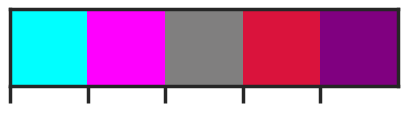

In [2]:
pal=sns.blend_palette(['cyan', 'magenta','gray','crimson','purple'], 5)
sns.palplot(pal)
sns.set_palette(pal)

In [3]:
sp_dims = (15, 5) #(width, height)
v_max = 4
v_min = -1
xvalues = np.arange(start=0, stop=3, step=0.5)
y_min = -2
y_max = 6

---

# Load in dfs

In [4]:
final_df = pd.read_parquet(r"U:\Papers\FX Behavior paper\data\final_V1HPC_OperantNovel_psth.parquet")

final_df.columns

Index(['stim_id', 'times', 'cuid', 'depth', 'Hz', 'zscore', 'ztc', 'region',
       'group', 'cc', 'et', 'r_groups', 'visRes'],
      dtype='object')

---

## Select what brain region you want

In [5]:
final_df.region.unique()

array(['hippo', 'v1'], dtype=object)

In [6]:
brain_region = 'v1'
# brain_region = 'hippo'

reg_final = final_df[(final_df.region == brain_region)&(final_df.visRes=='yes')] #Only 1 brain region and + visResp
reg_final.reset_index(drop=True, inplace=True)


In [7]:
# rew_df = reg_final[(reg_final['stim_id'] == 0)]
# rew2_df = reg_final[(reg_final['stim_id'] == 1)]
# unrew_df = reg_final[(reg_final['stim_id'] == 2)]
# novel_df = reg_final[(reg_final['stim_id'] == 9)]

# wt_rew_df = rew_df[(rew_df['group'] == 'WT')]
# wt_rew2_df = rew2_df[(rew2_df['group'] == 'WT')]
# wt_unrew_df = unrew_df[(unrew_df['group'] == 'WT')]
# fx_rew_df = rew_df[(rew_df['group'] == 'FX')]
# fx_rew2_df = rew2_df[(rew2_df['group'] == 'FX')]
# fx_unrew_df = unrew_df[(unrew_df['group'] == 'FX')]

---

## Sort units by rew situation sorting

In [135]:
val_wt_rew, val_wt_rew2, val_wt_unrew = mz_udf.unit_sorting(wt_rew_df, wt_rew2_df, wt_unrew_df, dfs_array='dfs')
val_fx_rew, val_fx_rew2, val_fx_unrew = mz_udf.unit_sorting(fx_rew_df, fx_rew2_df, fx_unrew_df, dfs_array='dfs')

In [136]:
#check the shape real quick to make sure it is all matching
print(val_wt_rew.shape)
print(val_wt_rew2.shape)
print(val_wt_unrew.shape)

print(val_fx_rew.shape)
print(val_fx_rew2.shape)
print(val_fx_unrew.shape)

(477, 300)
(477, 300)
(477, 300)
(334, 300)
(334, 300)
(334, 300)


---

# Quantify the unit preference by firing rate
### Go and Nogo index values

In [38]:
wt_go, wt_nogo, wt_osi = mz_udf.unit_pref_idx(val_wt_rew, val_wt_unrew)
fx_go, fx_nogo, fx_osi = mz_udf.unit_pref_idx(val_fx_rew, val_fx_unrew)

## Classify units into 3 groups (go pref, nogo pref, none)

In [39]:
wt_df = pd.DataFrame({'cuid':val_wt_rew.index.values, 'score':wt_osi, 'group':'wt'})
fx_df = pd.DataFrame({'cuid':val_fx_rew.index.values, 'score':fx_osi, 'group':'fx'})

my_std = 1.0

wt_std = wt_df[wt_df.group == 'wt']['score'].std()*my_std
fx_std = fx_df[fx_df.group == 'fx']['score'].std()*my_std
# wt_std = 0.5
# fx_std = 0.5
print(wt_std, fx_std)

wt_df['pref'] = wt_df['score'].apply(lambda x: 'Go' if x>wt_std else ('Nogo' if x<(wt_std*-1) else 'None'))
fx_df['pref'] = fx_df['score'].apply(lambda x: 'Go' if x>fx_std else ('Nogo' if x<(fx_std*-1) else 'None'))

unit_pref_df = pd.concat([wt_df, fx_df]).dropna()

0.3728598208498467 0.35957412796805194


## ANOVA test on the $\frac{(G-N)}{(G+N)}$ results

In [40]:
wt_si = unit_pref_df[unit_pref_df.group=='wt']['score'].values
fx_si = unit_pref_df[unit_pref_df.group=='fx']['score'].values

In [41]:
sstat.f_oneway(wt_si, fx_si)

F_onewayResult(statistic=3.1513119977192545, pvalue=0.07642810013407798)

## Plot preference
### pie charts

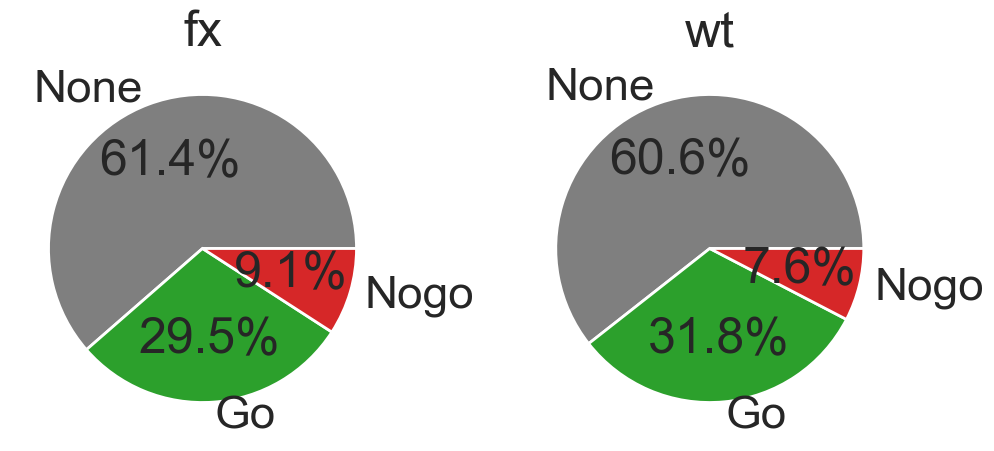

In [42]:
def fmt(x):
    return '{:.1f}%'.format(x)

colours = {'None': 'tab:grey', 'Go': 'tab:green', 'Nogo': 'tab:red'}
fig,ax = plt.subplots(1,2, figsize=(12,5))
i=0
for d,dd in unit_pref_df.groupby('group'):
    ax[i].set_title(d)
    total = dd['pref'].value_counts()
    ax[i].pie(total.values, labels=total.index, autopct=fmt, colors=[colours[key] for key in total.index])
    i+=1

# save_folder = r"C:\Users\AChub_Lab\Desktop\unit_pref_GNG"
# overall_path = save_folder + "\\" + f"{brain_region}_wtfx_GNGpref_pie.pdf"
# plt.savefig(overall_path)
    
plt.show()

In [43]:
print(f'fx:{29.5/9.1}, wt:{31.8/7.6}')

fx:3.241758241758242, wt:4.184210526315789


## scatter plot

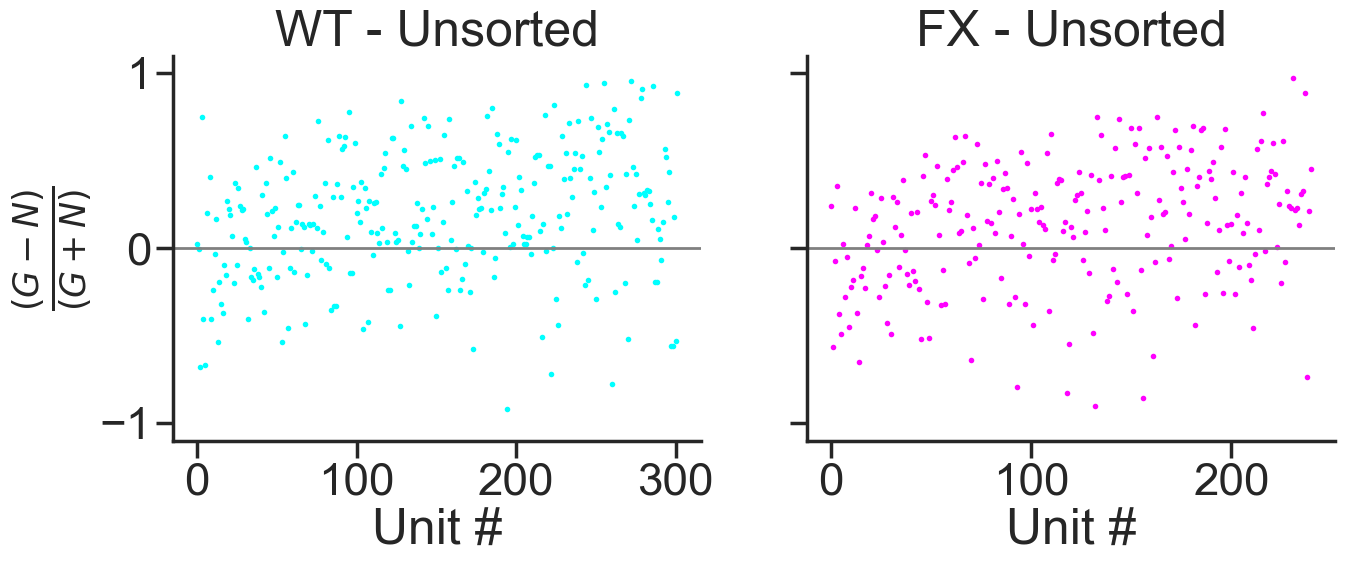

In [44]:
plt_label = r"$\frac{(G-N)}{(G+N)}$"

f,ax = plt.subplots(1,2, sharey=True, figsize=(15,5))
ax[0].scatter(range(len(wt_si)), wt_si, s=4, color='cyan')
ax[0].set_ylim([-1.1,1.1])
ax[0].set_xticks([0,100,200,300])
ax[0].set_xlabel('Unit #')
ax[0].set_ylabel(plt_label)
ax[0].set_title('WT - Unsorted')

ax[1].scatter(range(len(fx_si)), fx_si, s=4, color='magenta')
ax[1].set_xlabel('Unit #')
ax[1].set_title('FX - Unsorted')

ax[0].axhspan(0,0, color='grey', ls='-')
ax[1].axhspan(0,0, color='grey', ls='-')
sns.despine()

# save_folder = r"C:\Users\AChub_Lab\Desktop\unit_pref_GNG"
# overall_path = save_folder + "\\" + f"{brain_region}_wtfx_GNGpref_scatter.pdf"
# plt.savefig(overall_path)
    
plt.show()

## histogram

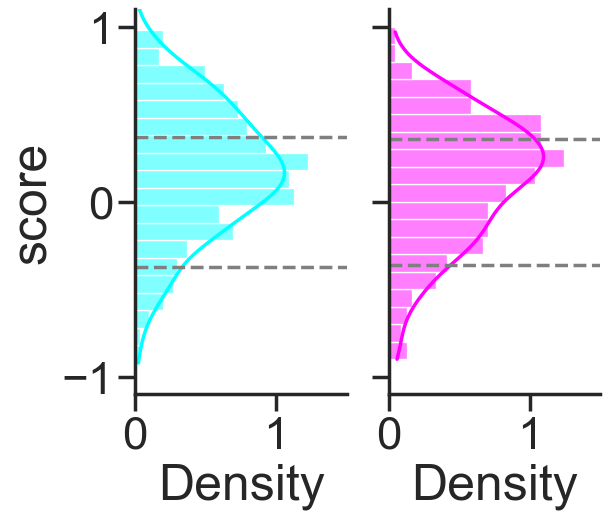

In [45]:
fig,ax = plt.subplots(1,2, sharey=True, sharex=True, figsize=(6,5))

sns.histplot(data=unit_pref_df[unit_pref_df.group=='wt'], y='score', binwidth=0.1, stat='density', kde=True, color='cyan', ec=None, ax=ax[0])
sns.histplot(data=unit_pref_df[unit_pref_df.group=='fx'], y='score', binwidth=0.1, stat='density', kde=True, color='magenta', ax=ax[1])
ax[0].set_ylim([-1.1,1.1])
ax[0].set_xlim(0,1.5)
ax[0].axhline(wt_std, ls='--', color='tab:grey')
ax[0].axhline(wt_std*-1, ls='--', color='tab:grey')
ax[1].axhline(fx_std, ls='--', color='tab:grey')
ax[1].axhline(fx_std*-1, ls='--', color='tab:grey')

sns.despine()
# save_folder = r"U:\Papers\FX Behavior paper\Figures\unit_pref_GNG"
# overall_path = save_folder + "\\" + f"{brain_region}_wtfx_GNGpref_yHistogram.pdf"
# plt.savefig(overall_path)
plt.show()

## 2d scatter

In [93]:
go_axis_A, nogo_axis_A = mz_udf.go_nogo_activity_plot(val_wt_rew, val_wt_unrew)
go_axis_B, nogo_axis_B = mz_udf.go_nogo_activity_plot(val_fx_rew, val_fx_unrew)

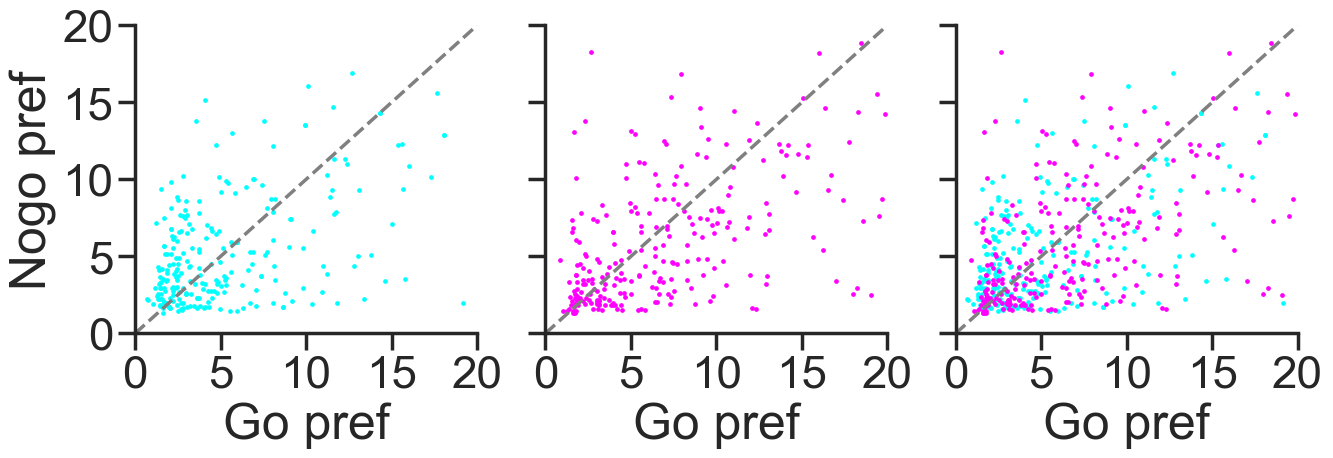

In [95]:
fig,ax = plt.subplots(1,3, figsize=(15,4), sharex=True, sharey=True)
ax[0].scatter(go_axis_A, nogo_axis_A, s=2, color='cyan')
ax[0].axline((0, 0), slope=1, color='grey', ls='--')
ax[0].set_xlim([0,20])
ax[0].set_xticks([0,5,10,15,20])
ax[0].set_ylim([0,20])
ax[0].set_yticks([0,5,10,15,20])
ax[0].set_xlabel('Go pref')
ax[0].set_ylabel('Nogo pref')

ax[1].scatter(go_axis_B, nogo_axis_B, s=2, color='magenta')
ax[1].axline((0, 0), slope=1., color='grey', ls='--')
ax[1].set_xlabel('Go pref')

ax[2].axline((0, 0), slope=1., color='grey', ls='--')
ax[2].scatter(go_axis_A, nogo_axis_A, s=2, color='cyan')
ax[2].scatter(go_axis_B, nogo_axis_B, s=2, color='magenta')
ax[2].set_xlabel('Go pref')

sns.despine()
# save_folder = r"C:\Users\AChub_Lab\Desktop\unit_pref_GNG"
# overall_path = save_folder + "\\" + f"{brain_region}_wtfx_GNGpref_2dscatter.pdf"
# plt.savefig(overall_path)
plt.show()

---

## Looking only at units w/ preference
### Plot the group heatmaps

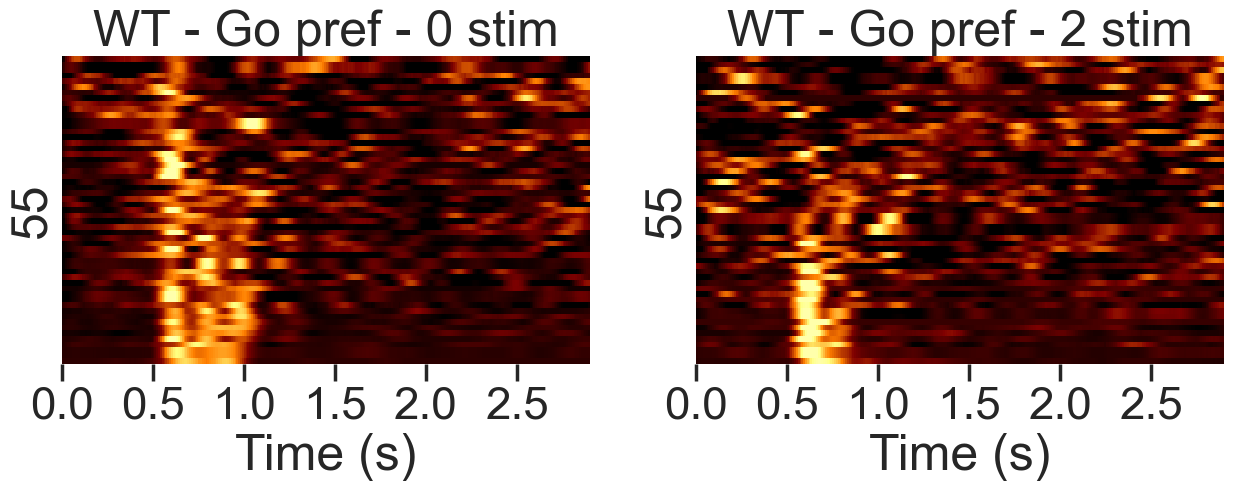

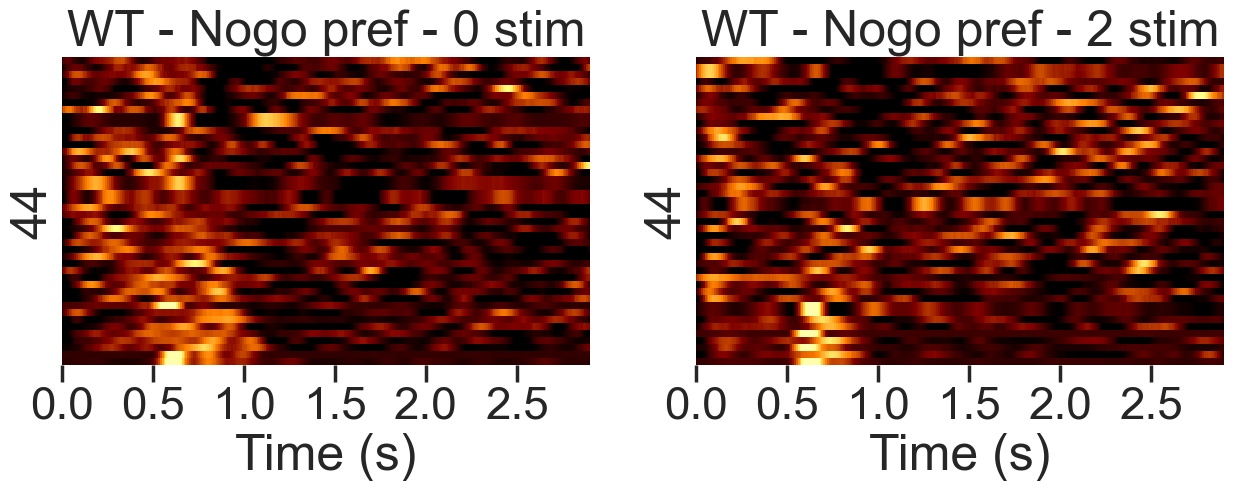

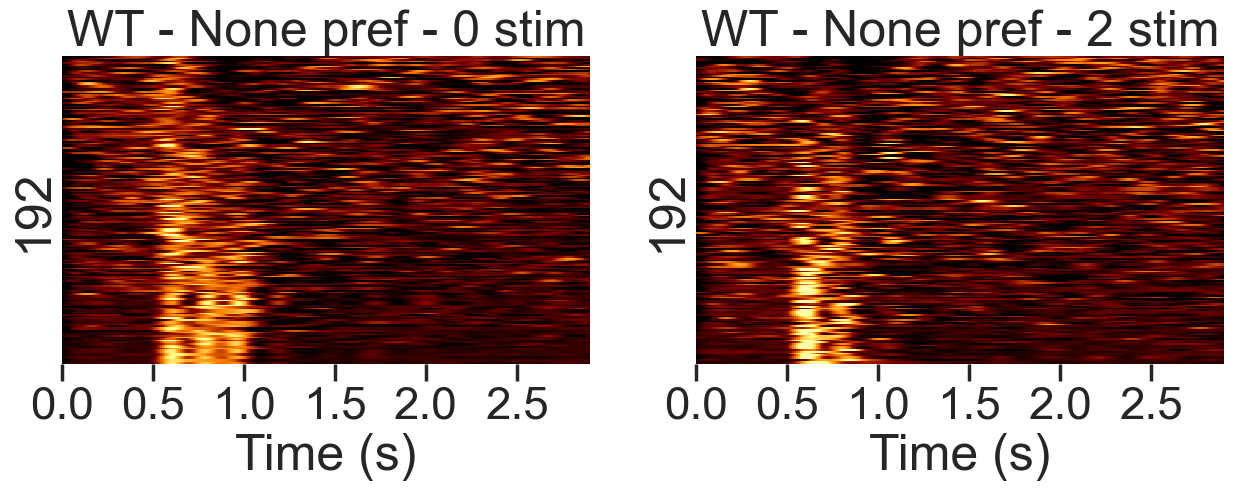

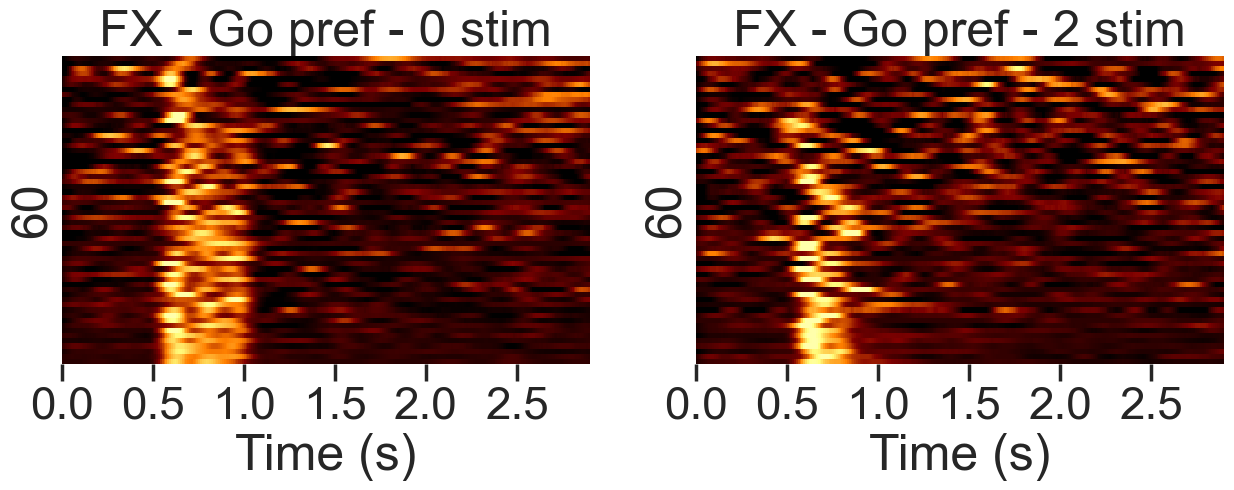

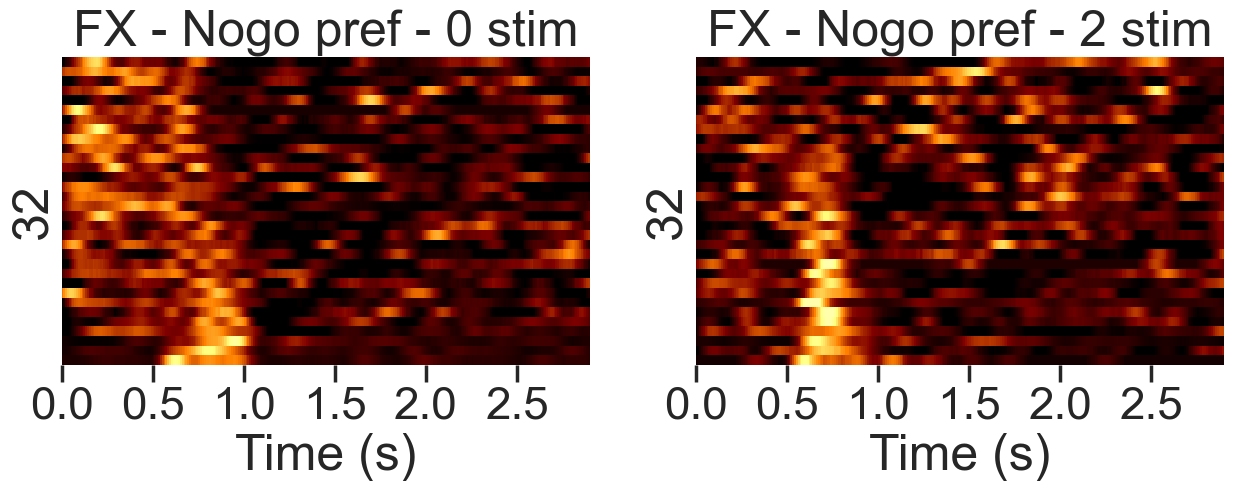

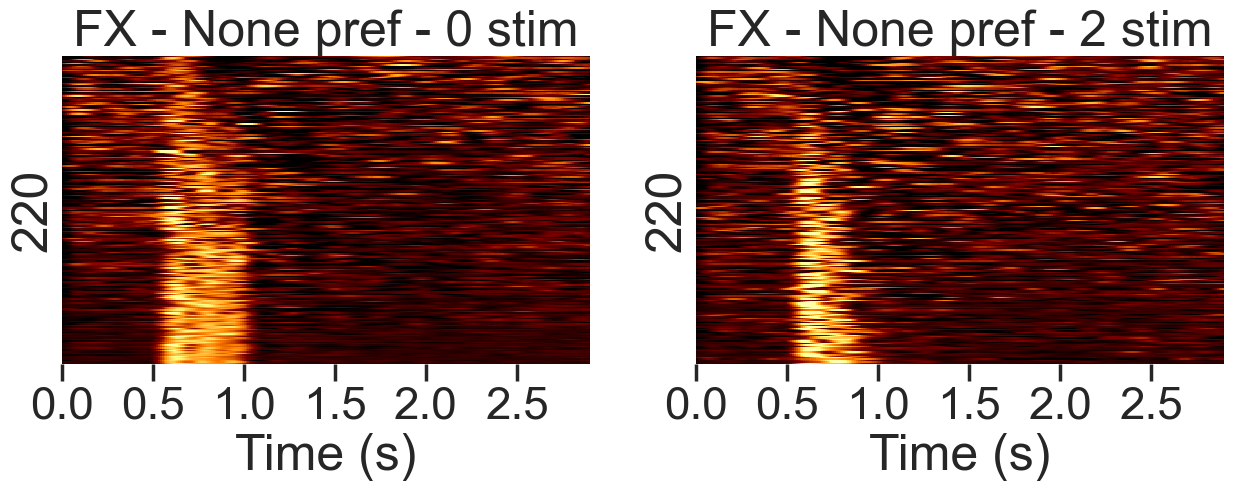

In [101]:
sp_dims = (15, 6) #(width, height)
v_max, v_min = 4, -1
xvalues = np.arange(start=0, stop=3, step=0.5)
y_max, y_min = 6, -2

for gg in ['WT','FX']:
    for xx in ['Go','Nogo','None']:
        wtfx_pref_ls = unit_pref_df[unit_pref_df.pref==xx].cuid.unique() #get cuid of units with preference to each stim (with each loop)
        unitPref = final_df[final_df['cuid'].isin(wtfx_pref_ls)]
        
        fig,ax = plt.subplots(1,2, figsize=(15,4))
        for idx, yy in enumerate([0,2]):
            WTunits = unitPref[(unitPref.group==gg)&(unitPref.region==brain_region)&(unitPref.stim_id==yy)]
            WTunits2 = WTunits.pivot(index='cuid', columns='times', values='zscore')
            WTunits_plot = WTunits2.values[ np.argsort(np.mean(WTunits2.values[:,50:100], axis=1) )] #if I want sorted activity across 0.5 to 1.5 sec window
            sns.heatmap(WTunits_plot, cmap = 'afmhot', xticklabels=50, yticklabels=False, vmax=v_max, center=2, vmin=v_min, robust=True, ax=ax[idx], cbar=False)
            ax[idx].set_xlabel('Time (s)')
            ax[idx].set_ylabel(str(len(WTunits.cuid.unique())))
            ax[idx].set_xticks(ticks=[0,50,100,150,200,250], labels=xvalues, rotation=0)
            ax[idx].set_xlim(0,2.9*100)
            ax[idx].set_title(f'{gg} - {xx} pref - {yy} stim')
        
        # save_folder = r"C:\Users\AChub_Lab\Desktop\unit_pref_GNG"
        # overall_path = save_folder + "\\" + f"{brain_region}_{gg}_{xx}pref_{yy}stim_heatmaps.pdf"
        # plt.savefig(overall_path)

        plt.show()

# Oscillation Index (?)

In [8]:
stimName_dict = {0:'Go+', 1:'Go-', 2:'No-Go', 9:'Novel'}

final_df['stim_name'] = final_df['stim_id'].map(stimName_dict)
final_df.stim_name.unique()

array(['Go+', 'Go-', 'No-Go', 'Novel'], dtype=object)

In [9]:
from sklearn.metrics import auc
def get_unit_psd(unit_df):
    unit_arr = unit_df.ztc.values
    freq = np.arange(unit_arr.shape[0]) / unit_arr.shape[0] * 100
    freq = freq[:freq.shape[0]//2]
    f = np.fft.fft(unit_arr)
    magnitude_spectrum = (np.abs(f)[:freq.shape[0]])
    indices = (freq >= 4)  & (freq <= 8)
    x, y = freq[indices], magnitude_spectrum[indices]
    return auc(x, y)

In [10]:
# osc_df = pd.DataFrame()
osc_ls = []
# for u,uu in final_df[(final_df.stim_id != 9)&(final_df.visRes=='yes')].groupby(['cuid','region']):
for u,uu in final_df[final_df.stim_id != 9].groupby(['cuid','region']):
    go_unit = uu[(uu.stim_name=='Go+')&(uu.times>=0.5)&(uu.times<=2.0)]
    nogo_unit = uu[(uu.stim_name=='No-Go')&(uu.times>=0.5)&(uu.times<=2.0)]
    group = uu.group.unique()[0]
    depth = uu.depth.unique()[0]
    go_psd, nogo_psd = 0, 0
    if len(go_unit):
        go_psd = get_unit_psd(go_unit)
    if len(nogo_unit):
        nogo_psd = get_unit_psd(nogo_unit)
    try:
        osc_score = (go_psd - nogo_psd) / (go_psd + nogo_psd)
    except:
        osc_score = 0
    osc_ls.append([u[1], u[0], group, go_psd, nogo_psd, osc_score, depth])
    
osc_df = pd.DataFrame(osc_ls, columns=['region', 'cuid', 'group', 'go_psd', 'nogo_psd', 'osc_score', 'depth'])

## Scatterplots

In [35]:


my_thresh = 0.65



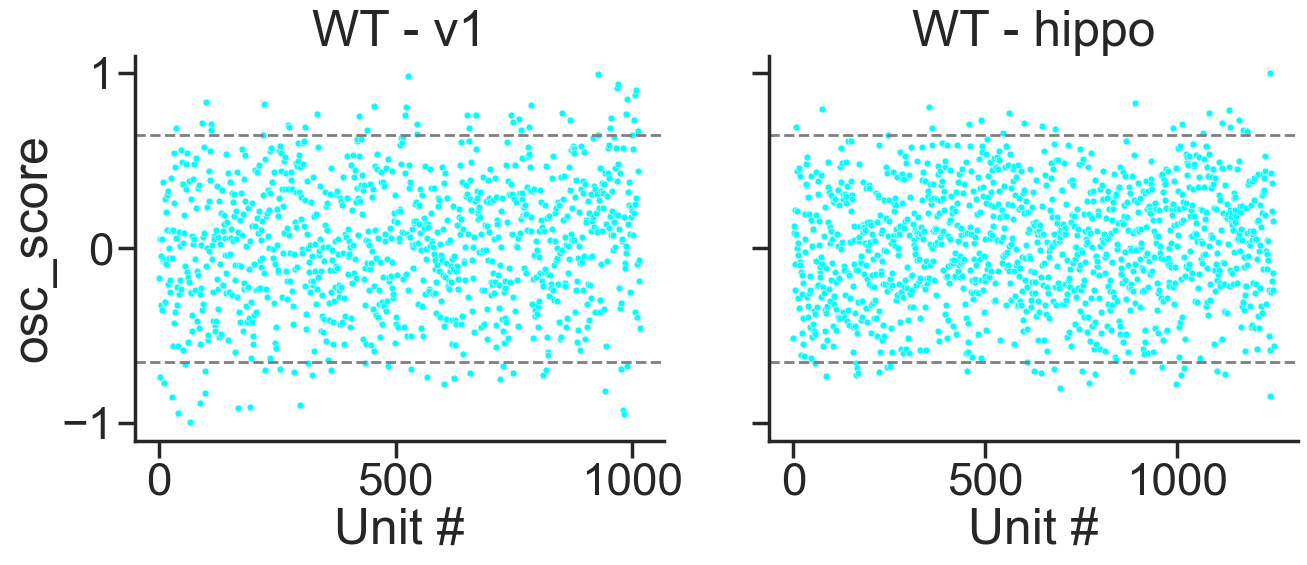

In [36]:
fig,ax =plt.subplots(1,2, figsize=(15,5), sharey=True)
for i,reg in enumerate(['v1','hippo']):
    my_plot = osc_df[(osc_df.region==reg)&(osc_df.group=='WT') & (abs(osc_df.osc_score) >= 0)]
    sns.scatterplot(data=my_plot, x=np.arange(len(my_plot)), y='osc_score', s=25, legend=False, color='cyan', ax=ax[i])
    ax[i].set_title(f'WT - {reg}')
    ax[i].axhline(-my_thresh, color='tab:gray', ls='--', lw=2)
    ax[i].axhline(my_thresh, color='tab:gray', ls='--', lw=2)
ax[0].set_ylim([-1.1,1.1])
ax[0].set_xlabel('Unit #')
ax[1].set_xlabel('Unit #')
sns.despine()

# save_folder = r"U:\Papers\FX Behavior paper\Figures\unit_pref_GNG\Oscillation_index"
# overall_path = save_folder + "\\" + f"v1hpc_wt_{my_thresh}thresh_oscIdx_scatter.pdf"
# plt.savefig(overall_path)
plt.show()

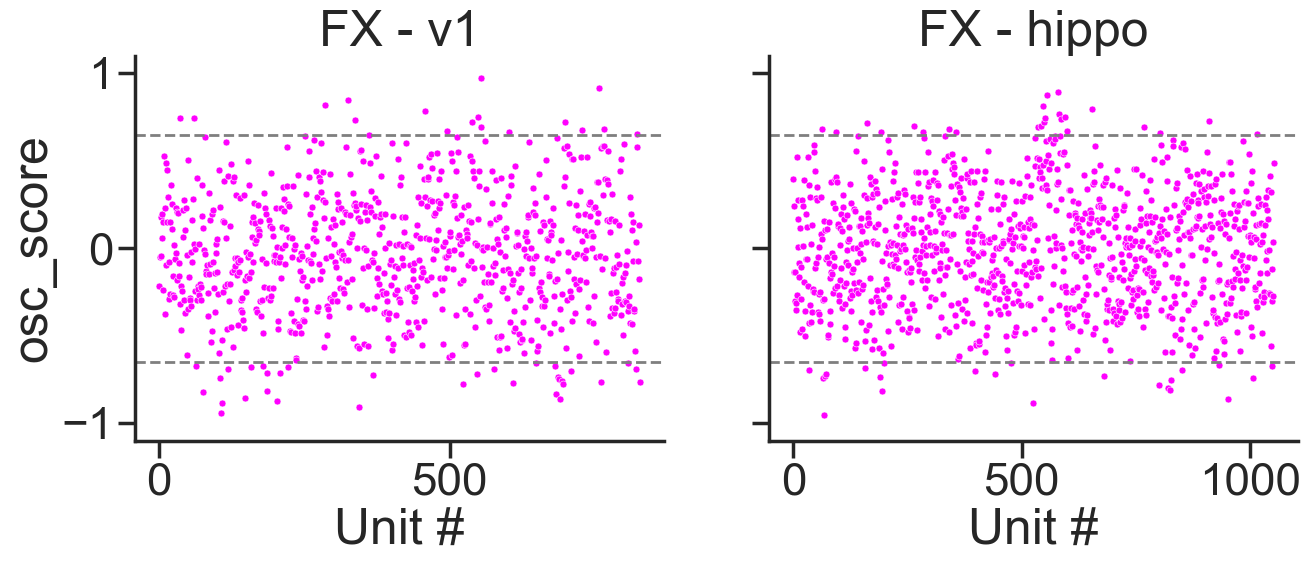

In [37]:
fig,ax =plt.subplots(1,2, figsize=(15,5), sharey=True)
for i,reg in enumerate(['v1','hippo']):
    my_plot = osc_df[(osc_df.region==reg)&(osc_df.group=='FX') & (abs(osc_df.osc_score)>=0)]
    sns.scatterplot(data=my_plot, x=np.arange(len(my_plot)), y='osc_score', s=25, legend=False, color='magenta', ax=ax[i])
    ax[i].set_title(f'FX - {reg}')
    ax[i].axhline(-my_thresh, color='tab:gray', ls='--', lw=2)
    ax[i].axhline(my_thresh, color='tab:gray', ls='--', lw=2)
ax[0].set_ylim([-1.1,1.1])
ax[0].set_xlabel('Unit #')
ax[1].set_xlabel('Unit #')
sns.despine()

# save_folder = r"U:\Papers\FX Behavior paper\Figures\unit_pref_GNG\Oscillation_index"
# overall_path = save_folder + "\\" + f"v1hpc_fx_{my_thresh}thresh_oscIdx_scatter.pdf"
# plt.savefig(overall_path)
plt.show()

## histogram

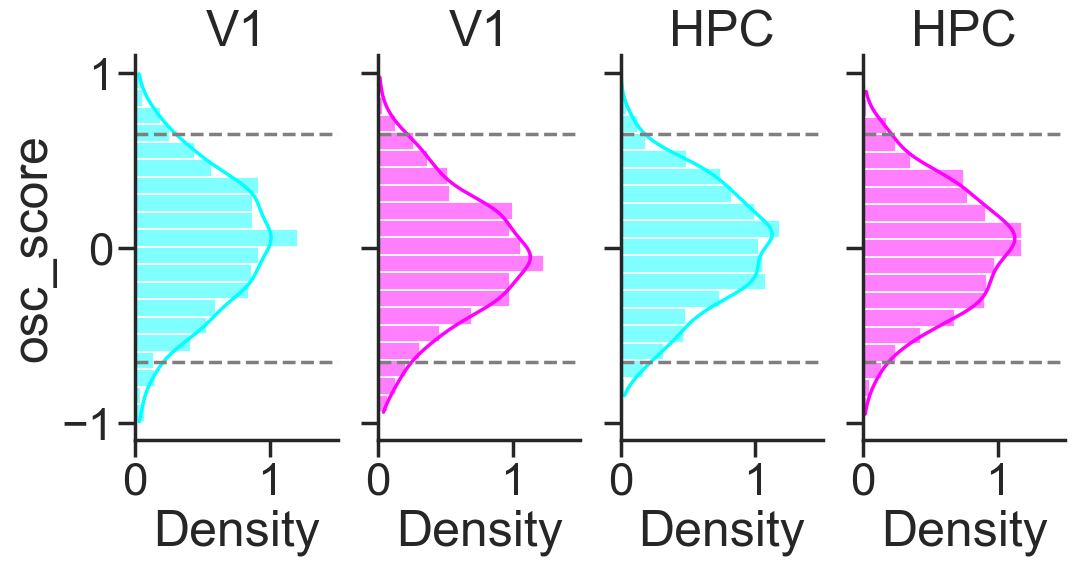

In [38]:
fig,ax = plt.subplots(1,4, sharey=True, sharex=True, figsize=(12,5))
sns.histplot(data=osc_df[(osc_df.group=='WT')&(osc_df.region=='v1')], y='osc_score', binwidth=0.1, stat='density', kde=True, color='cyan', ax=ax[0])
sns.histplot(data=osc_df[(osc_df.group=='FX')&(osc_df.region=='v1')], y='osc_score', binwidth=0.1, stat='density', kde=True, color='magenta', ax=ax[1])
sns.histplot(data=osc_df[(osc_df.group=='WT')&(osc_df.region=='hippo')], y='osc_score', binwidth=0.1, stat='density', kde=True, color='cyan', ax=ax[2])
sns.histplot(data=osc_df[(osc_df.group=='FX')&(osc_df.region=='hippo')], y='osc_score', binwidth=0.1, stat='density', kde=True, color='magenta', ax=ax[3])
ax[0].set_ylim([-1.1,1.1])
ax[0].set_xlim(0,1.5)
ax[0].set_title('V1')
ax[0].axhline(my_thresh, ls='--', color='tab:grey')
ax[0].axhline(my_thresh*-1, ls='--', color='tab:grey')
ax[1].set_title('V1')
ax[1].axhline(my_thresh, ls='--', color='tab:grey')
ax[1].axhline(my_thresh*-1, ls='--', color='tab:grey')
ax[2].set_title('HPC')
ax[2].axhline(my_thresh, ls='--', color='tab:grey')
ax[2].axhline(my_thresh*-1, ls='--', color='tab:grey')
ax[3].set_title('HPC')
ax[3].axhline(my_thresh, ls='--', color='tab:grey')
ax[3].axhline(my_thresh*-1, ls='--', color='tab:grey')
sns.despine()

# save_folder = r"U:\Papers\FX Behavior paper\Figures\unit_pref_GNG\Oscillation_index"
# overall_path = save_folder + "\\" + f"v1hpc_wtfx_{my_thresh}thresh_oscIdx_histogram.pdf"
# plt.savefig(overall_path)

plt.show()

# Pie chart

In [39]:
osc_df['pref'] = osc_df['osc_score'].apply(lambda x: 'Go' if x>my_thresh else ('Nogo' if x<-my_thresh else 'None'))

osc_df.head()

,region,cuid,group,go_psd,nogo_psd,osc_score,depth,pref
0,hippo,CC067431_HP2_185,FX,63.903477,27.456913,0.398932,620,None
1,hippo,CC067431_HP2_189,FX,95.211128,58.105556,0.242019,620,None
2,hippo,CC067431_HP2_191,FX,34.206785,44.867247,-0.134816,620,None
3,hippo,CC067431_HP2_193,FX,81.854530,107.227322,-0.134189,600,None
4,hippo,CC067431_HP2_198,FX,34.221709,63.339600,-0.298457,600,None


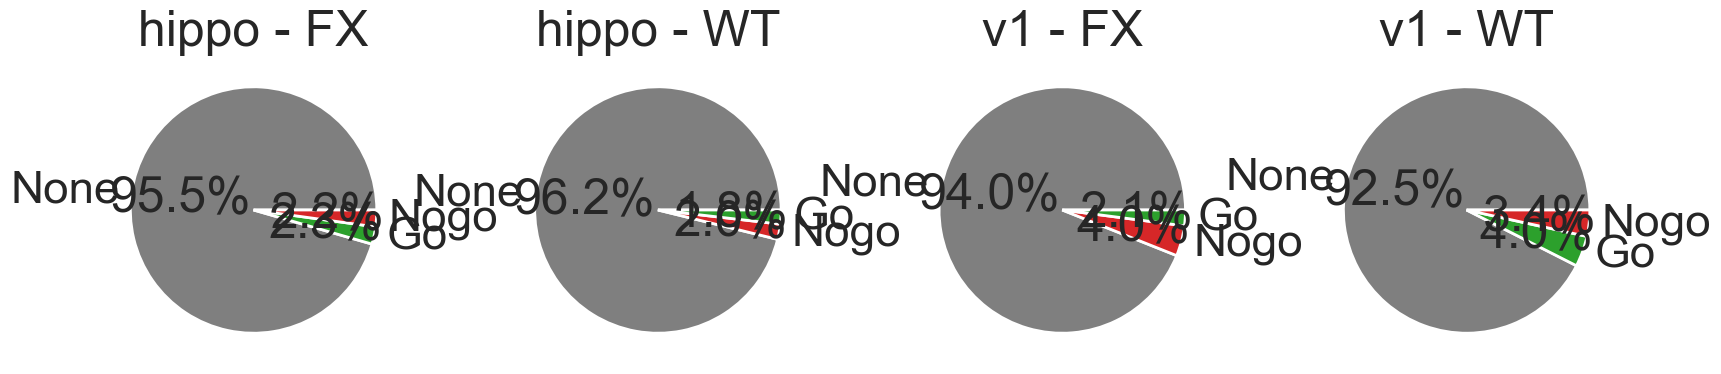

In [40]:
def fmt(x):
    return '{:.1f}%'.format(x)

colours = {'None': 'tab:grey', 'Go': 'tab:green', 'Nogo': 'tab:red'}
fig,ax = plt.subplots(1,4, figsize=(20,4))
i=0
for d,dd in osc_df.groupby(['region','group']):
    ax[i].set_title(f'{d[0]} - {d[1]}')
    total = dd['pref'].value_counts()
    ax[i].pie(total.values, labels=total.index, autopct=fmt, colors=[colours[key] for key in total.index])
    i+=1

# save_folder = r"U:\Papers\FX Behavior paper\Figures\unit_pref_GNG\Oscillation_index"
# overall_path = save_folder + "\\" + f"v1hpc_wtfx_{my_thresh}thresh_oscIdx_pie.pdf"
# plt.savefig(overall_path)
plt.show()

# Plot zscore of all units outside threshold

In [24]:
print(osc_df.group.unique())
print(osc_df.region.unique())

['FX' 'WT']
['hippo' 'v1']


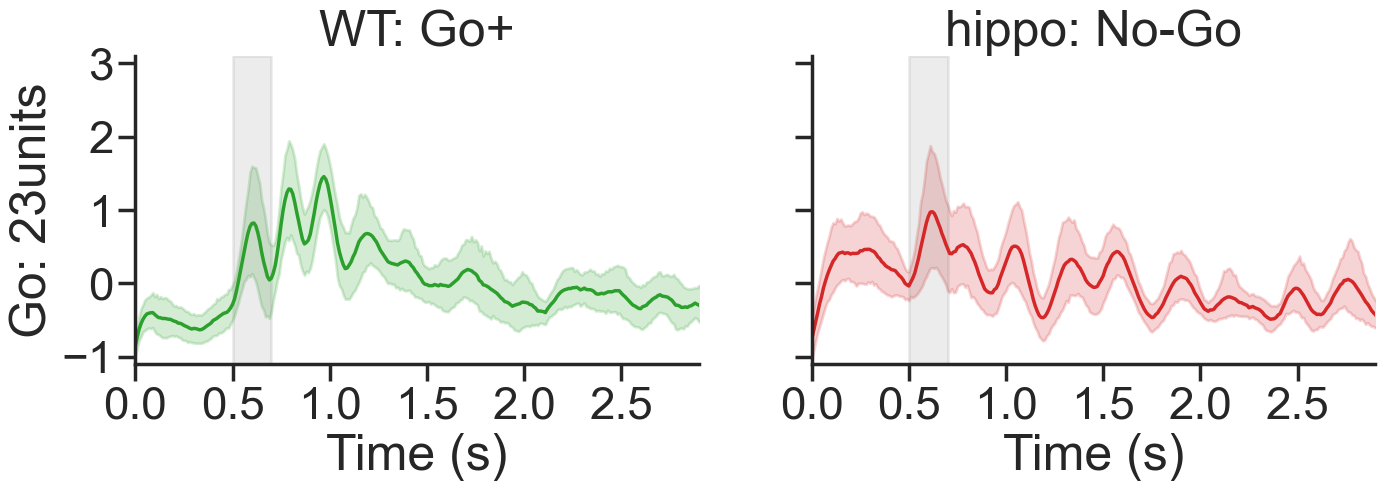

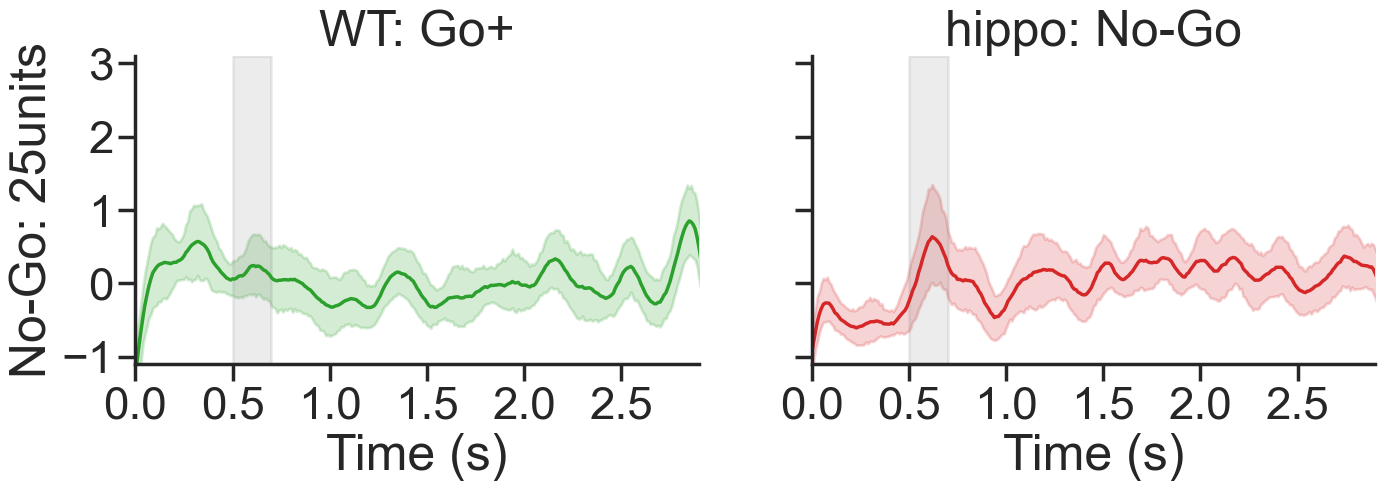

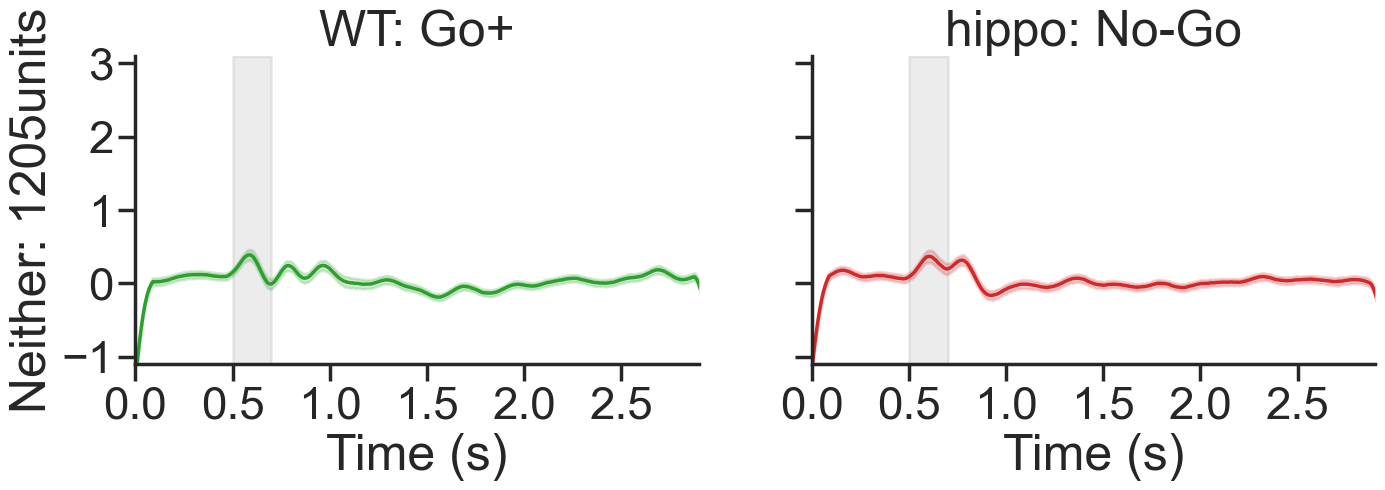

In [46]:
my_region = 'hippo'
my_group = 'WT'
metr='zscore'
my_thresh = 0.65

for what_pref in ['Go', 'No-Go', 'Neither']:
    if what_pref == 'Go':
        my_plot = osc_df[(osc_df.region==my_region) & (osc_df.group==my_group) & (osc_df.osc_score>my_thresh)]
    elif what_pref == 'No-Go':
        my_plot = osc_df[(osc_df.region==my_region) & (osc_df.group==my_group) & (osc_df.osc_score<-my_thresh)]
    else:
        my_plot = osc_df[(osc_df.region==my_region) & (osc_df.group==my_group) & (abs(osc_df.osc_score)<my_thresh)]
    
    cuid_ls = my_plot.cuid.unique()
    pref_unit_df = final_df[final_df['cuid'].isin(cuid_ls)] #only include units with pref (from above lines)
    go_plt_df = pref_unit_df[pref_unit_df.stim_name == 'Go+']
    nogo_plt_df = pref_unit_df[pref_unit_df.stim_name == 'No-Go']
    
    fig, ax = plt.subplots(1, 2, figsize=(16, 4), sharey=True, sharex=True)
    sns.lineplot(data=go_plt_df, x='times', y=metr, color='tab:green', ax=ax[0])
    sns.lineplot(data=nogo_plt_df, x='times', y=metr, color='tab:red', ax=ax[1])
    ax[0].set_title(f'{my_group}: Go+')
    ax[0].axvspan(0.5,0.7, color='grey', alpha=0.15)
    ax[1].set_title(f'{my_region}: No-Go')
    ax[1].axvspan(0.5,0.7, color='grey', alpha=0.15)
    ax[0].set_ylabel(f'{what_pref}: {len(cuid_ls)}units')
    ax[0].set_xticks([0,0.5,1.0,1.5,2.0,2.5])
    ax[0].set_yticks([-1,0,1,2,3])
    ax[0].set_xlim([0,2.9])
    ax[0].set_ylim([-1.1,3.1])
    ax[0].set_xlabel('Time (s)')
    ax[1].set_xlabel('Time (s)')
    sns.despine()
    
    # save_folder = r"U:\Papers\FX Behavior paper\Figures\unit_pref_GNG\Oscillation_index"
    # overall_path = save_folder + "\\" + f"{my_region}_{my_group}_{what_pref}pref_{metr}_{my_thresh}thresh_oscIdx_allUnitZScore.pdf"
    # plt.savefig(overall_path)
    
    plt.show()

# looking at the depth of these units

In [47]:
osc_df['m_depth'] = (osc_df.depth-3000)/1000 #adds mouse depth, 0 = surface of the brain

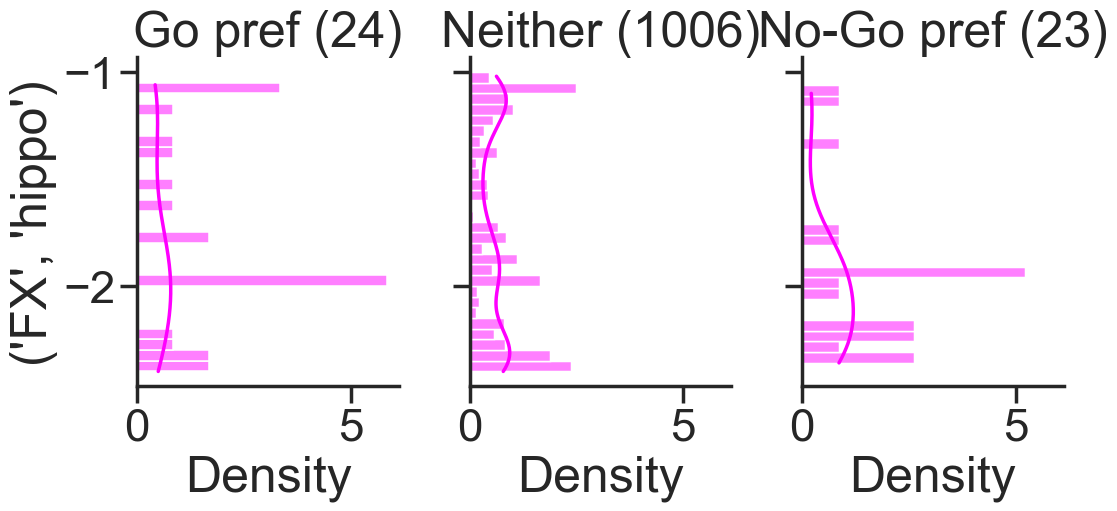

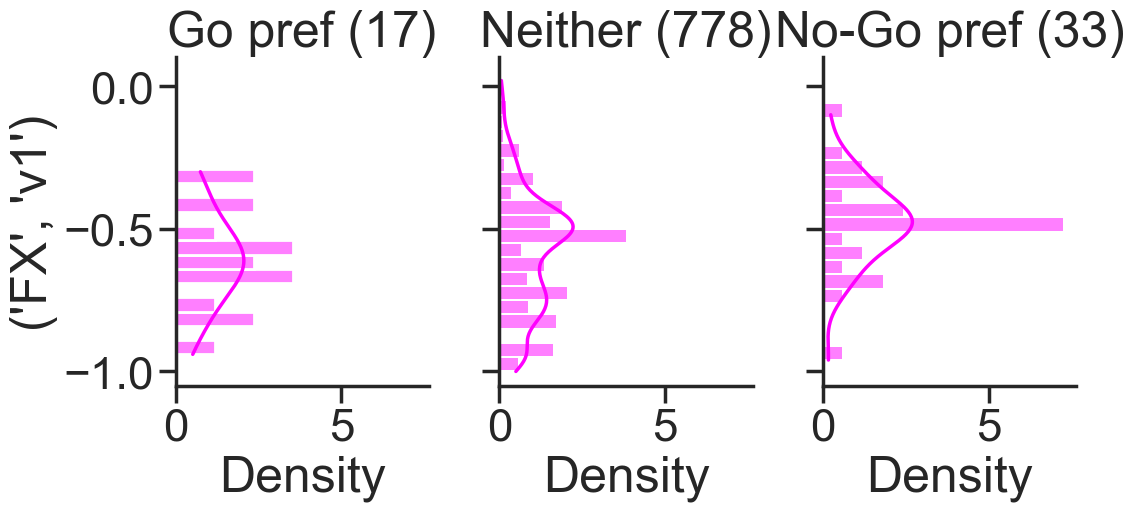

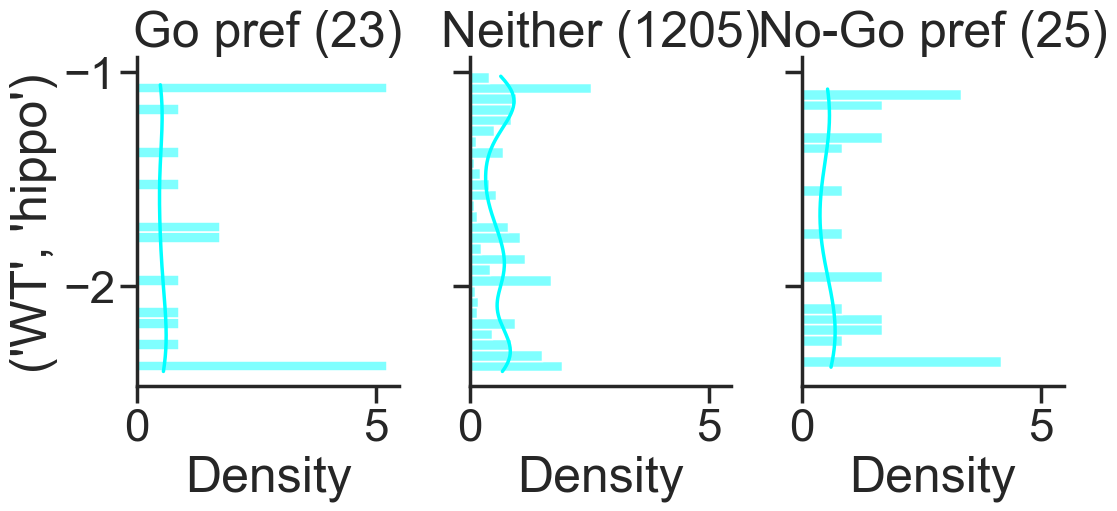

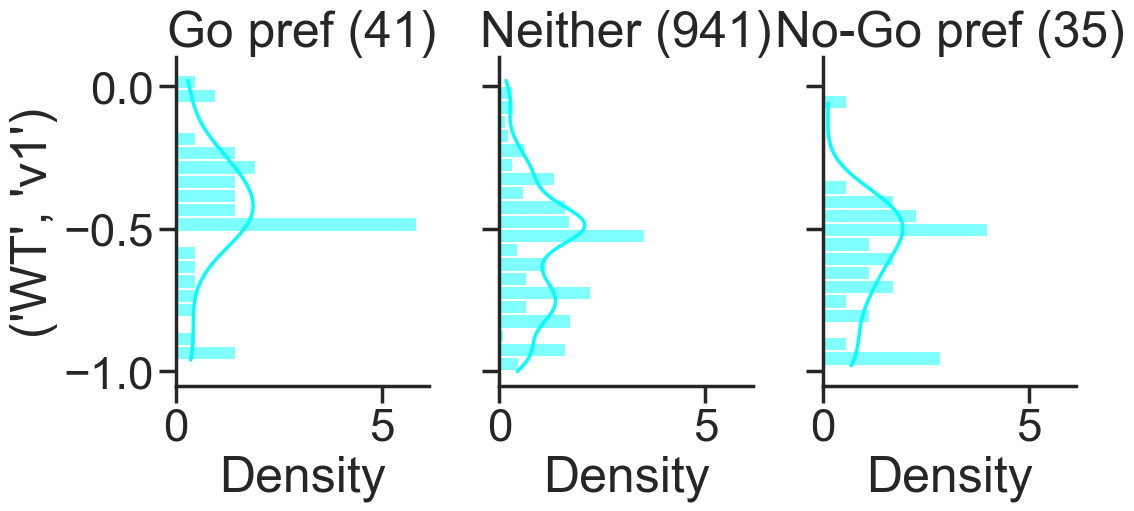

In [51]:
my_bins = 0.05 #0.01 means every 10 um
my_stat = 'density' #count, probability, density
my_thresh = 0.65

for d,dd in osc_df.groupby(['group','region']):
    fig,ax = plt.subplots(1,3, sharey=True, sharex=True, figsize=(12,6))
    ax = ax.ravel()
    plt_color='cyan' if d[0]=='WT' else 'magenta'
    sns.histplot(data=dd[dd.osc_score>my_thresh], y='m_depth', binwidth=my_bins, stat=my_stat, kde=True, color=plt_color, ax=ax[0])
    sns.histplot(data=dd[abs(dd.osc_score)<my_thresh], y='m_depth', binwidth=my_bins, stat=my_stat, kde=True, color=plt_color, ax=ax[1])
    sns.histplot(data=dd[dd.osc_score<-my_thresh], y='m_depth', binwidth=my_bins, stat=my_stat, kde=True, color=plt_color, ax=ax[2])
    ax[0].set_ylabel(d)
    ax[0].set_title(f'Go pref ({dd[dd.osc_score>my_thresh].cuid.nunique()})')
    ax[1].set_title(f'Neither ({dd[abs(dd.osc_score)<my_thresh].cuid.nunique()})')
    ax[2].set_title(f'No-Go pref ({dd[dd.osc_score<-my_thresh].cuid.nunique()})')
    sns.despine()
    plt.tight_layout()
    plt.show()

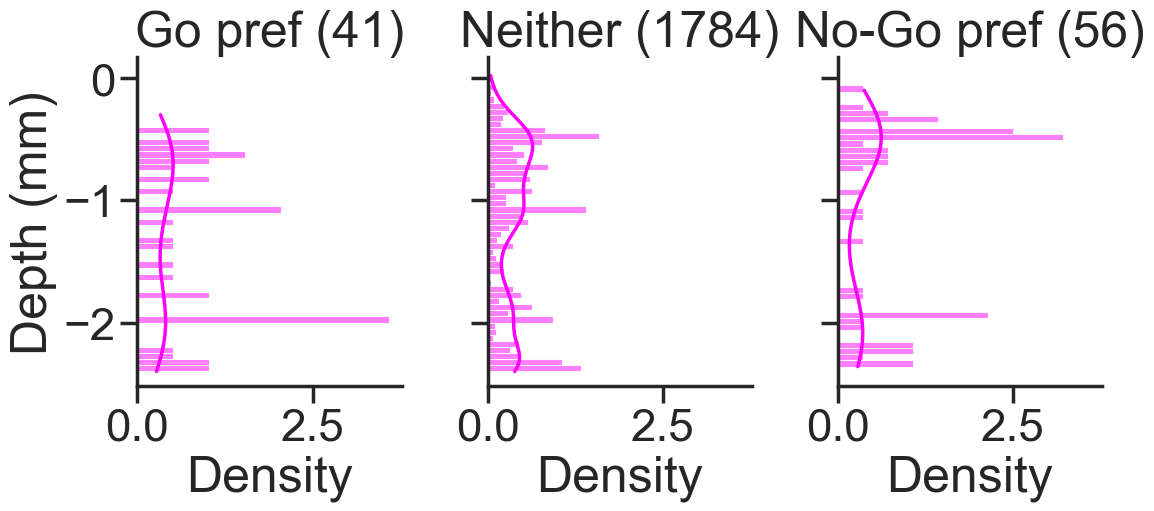

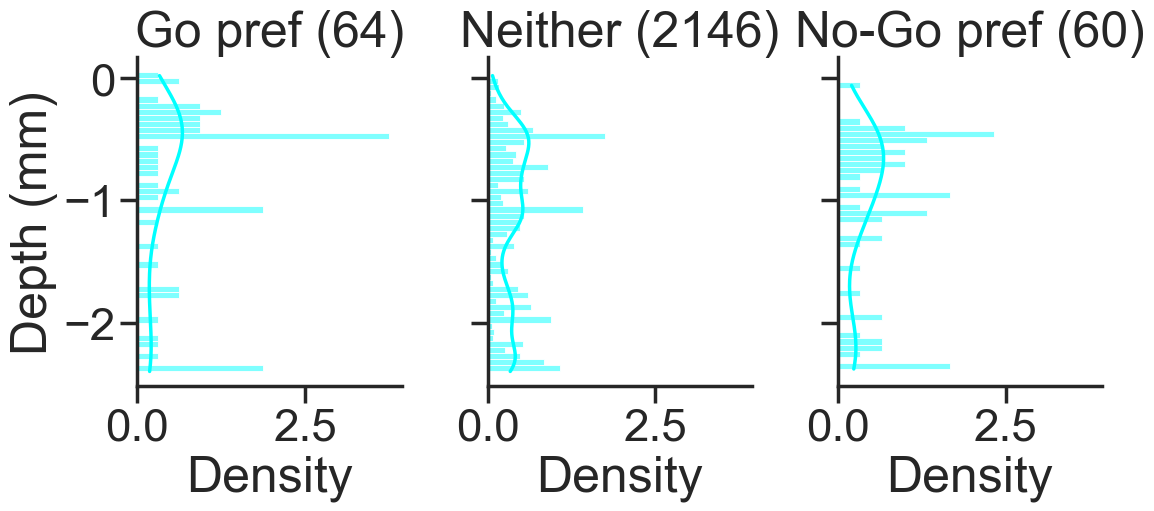

In [52]:
my_bins = 0.05 #0.01 means every 10 um
my_stat = 'density' #count, probability, density

for d,dd in osc_df.groupby('group'):
    fig,ax = plt.subplots(1,3, sharey=True, sharex=True, figsize=(12,6))
    ax = ax.ravel()
    plt_color='cyan' if d=='WT' else 'magenta'
    sns.histplot(data=dd[dd.osc_score>my_thresh], y='m_depth', binwidth=my_bins, stat=my_stat, kde=True, color=plt_color, ax=ax[0])
    sns.histplot(data=dd[abs(dd.osc_score)<my_thresh], y='m_depth', binwidth=my_bins, stat=my_stat, kde=True, color=plt_color, ax=ax[1])
    sns.histplot(data=dd[dd.osc_score<-my_thresh], y='m_depth', binwidth=my_bins, stat=my_stat, kde=True, color=plt_color, ax=ax[2])
    ax[0].set_ylabel('Depth (mm)')
    ax[0].set_title(f'Go pref ({dd[dd.osc_score>my_thresh].cuid.nunique()})')
    ax[1].set_title(f'Neither ({dd[abs(dd.osc_score)<my_thresh].cuid.nunique()})')
    ax[2].set_title(f'No-Go pref ({dd[dd.osc_score<-my_thresh].cuid.nunique()})')
    sns.despine()
    plt.tight_layout()
    plt.show()

In [54]:
# testing asthetic plots...
osc_df.pref.unique()

array(['None', 'Nogo', 'Go'], dtype=object)

In [55]:
osc_df['Anypref'] = osc_df['pref'].apply(lambda x: 'no' if x=='None' else 'yes')

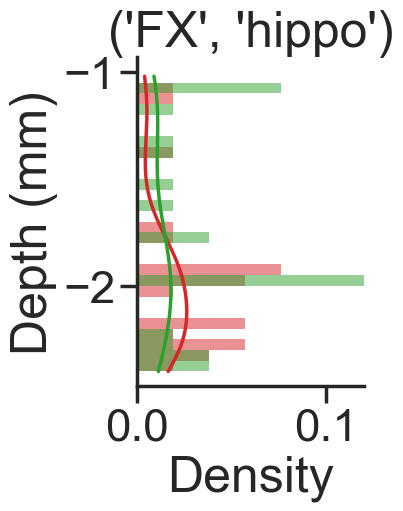

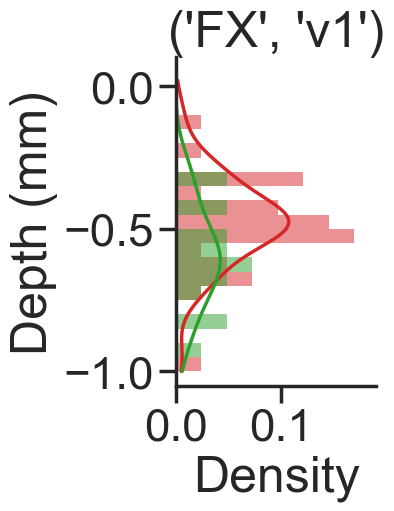

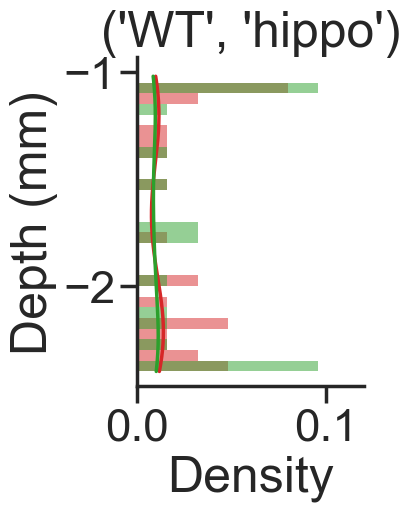

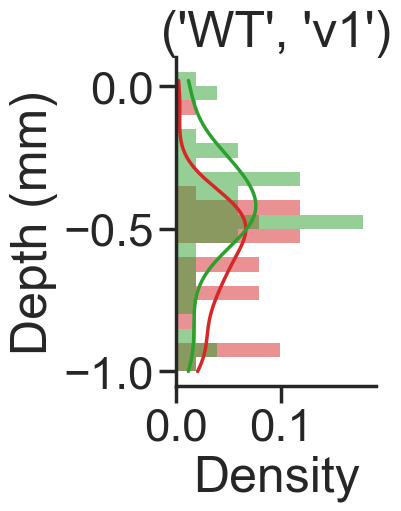

In [89]:
my_bins = 0.05 #0.01 means every 10 um
my_stat = 'density' #count, probability, density

for d,dd in osc_df.groupby(['group','region']):
    fig,ax = plt.subplots(1,1, sharey=True, sharex=True, figsize=(5,6))
    sns.histplot(data=dd, y='m_depth', hue='pref', hue_order=['Go','Nogo'], palette={'Go':'tab:green', 'Nogo':'tab:red'}, **{'lw':0},
                 binwidth=my_bins, stat=my_stat, kde=True, color=plt_color, ax=ax, legend=False)
    ax.set_ylabel('Depth (mm)')
    ax.set_title(f'{d}')
    if d[1] == 'v1':
        ax.set_xlim([0,0.19])
    else:
        ax.set_xlim([0,0.12])
    sns.despine()
    plt.tight_layout()

    # save_folder = r"U:\Papers\FX Behavior paper\Figures\unit_pref_GNG\Oscillation_index"
    # overall_path = save_folder + "\\" + f"{d[0]}_{d[1]}_oscIdx_oscillatorDepth.pdf"
    # plt.savefig(overall_path)
    
    plt.show()